In [1]:
import seaborn             as sns
import libraries.utilities as sul
import matplotlib.pyplot   as plt
import numpy               as np
import os

sns.set_theme()

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
# Define name of folder and path to reference POSCAR
general_folder = '/Users/cibran/Desktop/slabs/SbSeI-slab'
surface = '0_1_0_i_23'

path_to_confs   = f'{general_folder}/H-absorption/{surface}'
path_to_surface = f'{general_folder}/slabs/{surface}'
path_to_free_H  = f'{path_to_confs}/free-H'

In [3]:
# Read lattice vectors
lattice_vectors = sul.read_lattice_vectors(path_to_free_H)

# Read energies from each configuration
confs_data = {}
for conf in os.listdir(path_to_confs):
    if conf[:4] == 'conf':
        path_to_conf = f'{path_to_confs}/{conf}'
        energy               = sul.read_energy(path_to_conf)
        lattice_vectors_conf = sul.read_lattice_vectors(path_to_conf)

        # Lattice vectors match
        if np.allclose(lattice_vectors, lattice_vectors_conf):
            confs_data.update({
                conf: energy
            })
        else:
            print(f'Lattice vectors do not match for {conf}')

min_conf = min(confs_data, key=confs_data.get)
min_energy = confs_data[min_conf]
print(f'Minimum energy: {min_energy} for {min_conf}')

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/outputs.py:312: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/inputs.py:2655: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


Minimum energy: -400.94301606 eV for conf-9


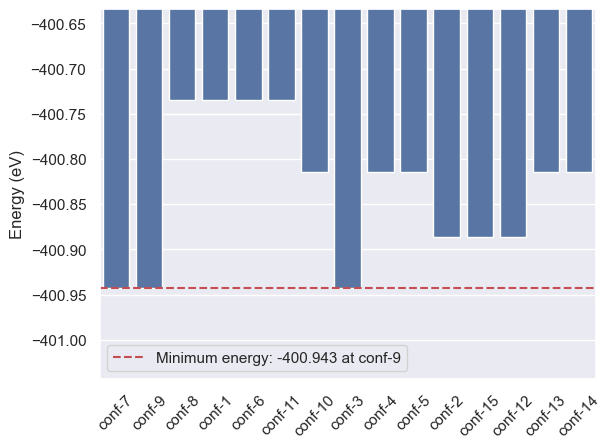

In [4]:
# Plot confs_data
sns.barplot(x=list(confs_data.keys()), y=list(confs_data.values()))
plt.axhline(y=min_energy, color='r', linestyle='--', label=f'Minimum energy: {min_energy:2g} at {min_conf}')
plt.xticks(rotation=45)
plt.ylim(min(confs_data.values())-0.1, max(confs_data.values())+0.1)
plt.ylabel('Energy (eV)')
plt.legend(loc='best')
plt.savefig(f'{general_folder}/H-absorption/{surface}/H-absorption.pdf', dpi=50)
plt.show()

In [5]:
# Get the number of replicas of the surface
path_to_min_conf = f'{path_to_confs}/{min_conf}'

# Extract the volumse of min_conf and surface
min_conf_volume = sul.read_volume(f'{path_to_confs}/{min_conf}')
surface_volume = sul.read_volume(path_to_surface)

# Calculate the number of replicas of the surface
n_replicas = int(min_conf_volume / surface_volume)
n_replicas

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/outputs.py:312: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/inputs.py:2655: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


3

In [6]:
# Extract energies of free H and surface
hydrogen_energy = sul.read_energy(path_to_free_H)
surface_energy  = sul.read_energy(path_to_surface)

In [7]:
# Compute hydrogen absorption energy
absorption_energy = min_energy - n_replicas*surface_energy - hydrogen_energy/2
absorption_energy

1.1637941149999738